In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, SimpleRNN, BatchNormalization

In [3]:
df = pd.read_csv('../Datasets/seattle-weather.csv')
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [4]:
# 4 características: precipitation, temp_max, temp_min, wind
features_data = df[['precipitation', 'temp_max', 'temp_min', 'wind']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(features_data)

print(scaled_data.shape)

(1461, 4)


In [5]:
def create_multistep_data(data, window_size=60, step_out=2):
    X, y = [], []
    for i in range(window_size, len(data) - step_out + 1):
        # X: Los 60 días pasados con las 4 características (índices 0 a 3)
        X.append(data[i-window_size:i, 0:4])
        # y: La columna 'temp_max' (índice 1) para el día i e i+1
        y.append(data[i : i + step_out, 1])
        
    return np.array(X), np.array(y)

In [6]:
timesteps = 60
X, y = create_multistep_data(scaled_data, window_size=timesteps, step_out=2)

print(f"X shape (muestras, tiempo, features): {X.shape}") # (N, 60, 4)
print(f"y shape (muestras, días_a_predecir): {y.shape}")  # (N, 2)

X shape (muestras, tiempo, features): (1400, 60, 4)
y shape (muestras, días_a_predecir): (1400, 2)


In [7]:
# Dividimos en entrenamiento (800), validación (200) y el resto para test
X_train, y_train = X[:800], y[:800]
X_val, y_val = X[800:1000], y[800:1000]
X_test, y_test = X[1000:], y[1000:]

print(f"Entrenamiento: {X_train.shape}, {y_train.shape}")
print(f"Validación: {X_val.shape}, {y_val.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")

Entrenamiento: (800, 60, 4), (800, 2)
Validación: (200, 60, 4), (200, 2)
Test: (400, 60, 4), (400, 2)


In [ ]:
model = Sequential([
    # Input: 60 días, 4 variables
    Input(shape=(timesteps, 4)),
    SimpleRNN(64, activation='relu', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    SimpleRNN(32, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(2) # Output: Temperatura máxima para los próximos 2 días
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,898 (34.76 KB)

 Trainable params: 8,770 (34.26 KB)

 Non-trainable params: 128 (512.00 B)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.4423 - mae: 0.5239 - val_loss: 0.2546 - val_mae: 0.5027
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1051 - mae: 0.2554 - val_loss: 0.2041 - val_mae: 0.4486
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0591 - mae: 0.1933 - val_loss: 0.1862 - val_mae: 0.4265
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0486 - mae: 0.1706 - val_loss: 0.1626 - val_mae: 0.3964
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0405 - mae: 0.1568 - val_loss: 0.1479 - val_mae: 0.3768
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0364 - mae: 0.1488 - val_loss: 0.1382 - val_mae: 0.3631
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0291 - mae: 0.1322 - val_loss: 0.1112 - val_mae: 0.3217
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0271 - mae: 0.1282 - val_loss: 0.1084 - val_mae: 0.3171
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - l

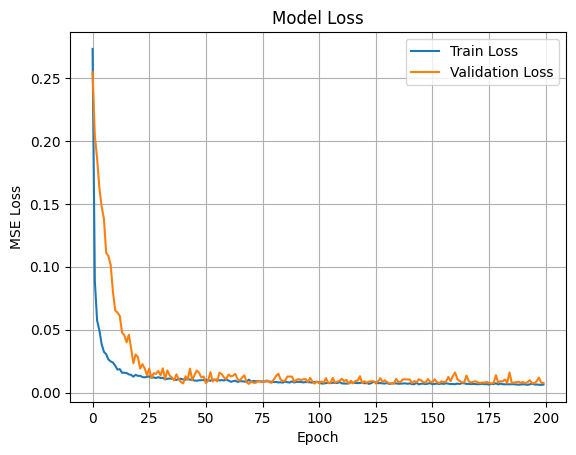

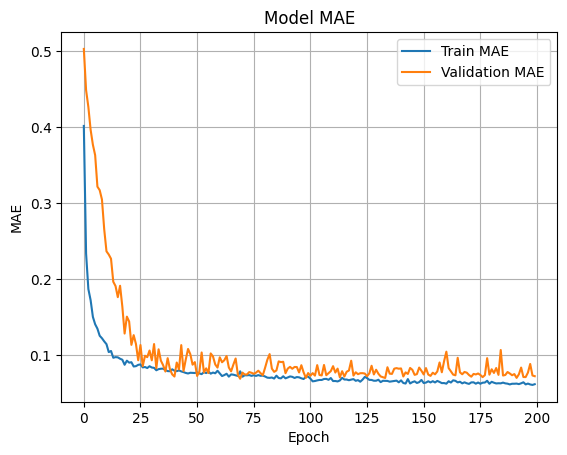

In [14]:
# --- Loss ---
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- MAE ---
plt.figure()
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model MAE')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
y_pred = model.predict(X_test)

temp_scaler = MinMaxScaler(feature_range=(0, 1))
temp_scaler.min_, temp_scaler.scale_ = scaler.min_[1], scaler.scale_[1]

y_pred_rescaled = (y_pred - temp_scaler.min_) / temp_scaler.scale_
y_test_rescaled = (y_test - temp_scaler.min_) / temp_scaler.scale_

rmse = np.sqrt(np.mean((y_test_rescaled - y_pred_rescaled)**2))
print(f"RMSE: {rmse}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
RMSE: 3.382992585750335


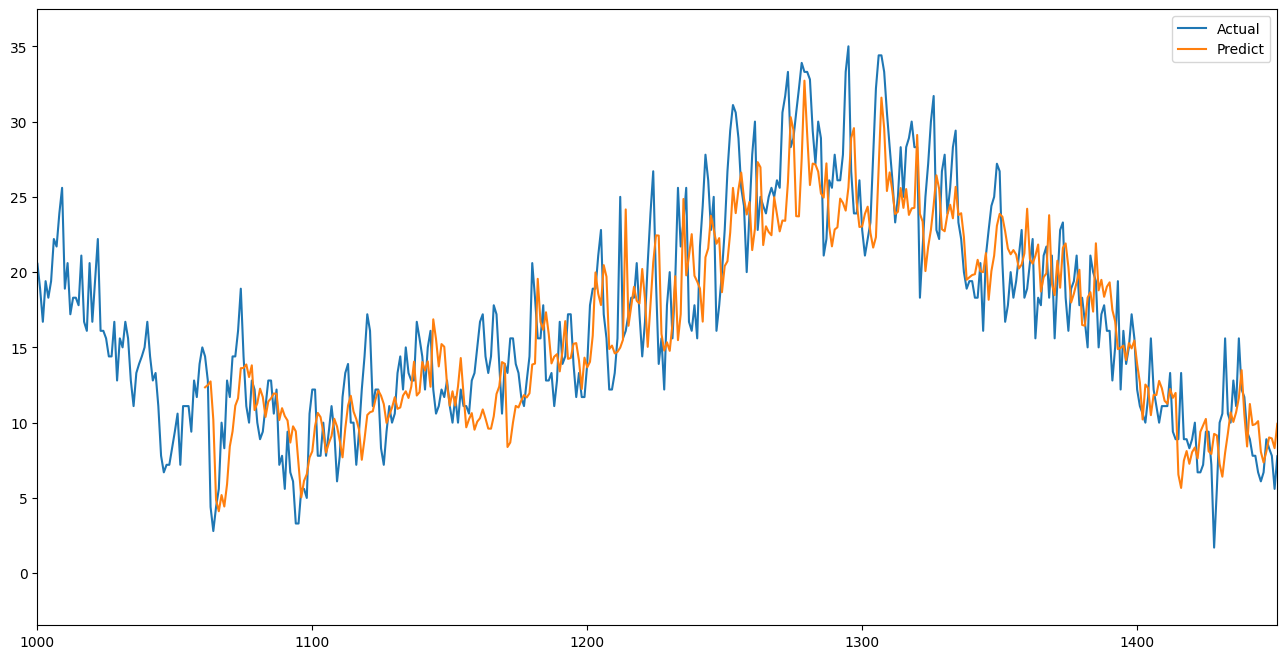

In [16]:
s_min = scaler.min_[1]
s_scale = scaler.scale_[1]
y_pred_grados = (y_pred - s_min) / s_scale
y_test_grados = (y_test - s_min) / s_scale

actual = df[['temp_max']]
indice_inicio = len(df) - len(y_pred_grados)
pred = df[['temp_max']].iloc[indice_inicio:].copy()

# Tomamos el Día 1 de la predicción ya convertida a grados
pred['Predict'] = y_pred_grados[:, 0] 

plt.figure(figsize=(16, 8))
plt.plot(actual, label='Actual')
plt.plot(pred['Predict'], label='Predict')
plt.legend()
plt.xlim([1000, 1451])
plt.show()

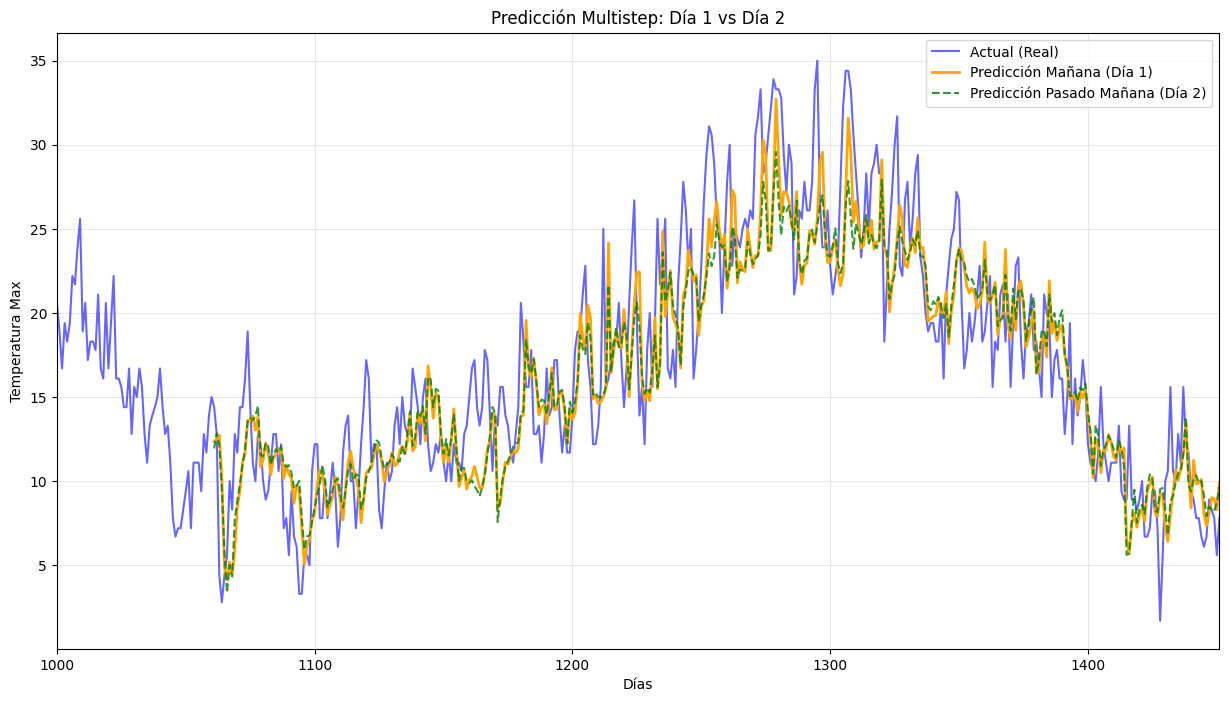

In [17]:
indice_inicio = len(df) - len(y_pred_grados)
pred_final = df[['temp_max']].iloc[indice_inicio:].copy()

pred_final['Predict_Dia1'] = y_pred_grados[:, 0]
pred_final['Predict_Dia2'] = y_pred_grados[:, 1]

plt.figure(figsize=(15, 8))
plt.plot(df.index[1000:], df['temp_max'].iloc[1000:], label='Actual (Real)', color='blue', alpha=0.6)

# Predicción Día 1
plt.plot(pred_final.index, pred_final['Predict_Dia1'], label='Predicción Mañana (Día 1)', color='orange', linewidth=2)
# Predicción Día 2
plt.plot(pred_final.index, pred_final['Predict_Dia2'], label='Predicción Pasado Mañana (Día 2)', color='green', linestyle='--', alpha=0.8)

plt.title('Predicción Multistep: Día 1 vs Día 2')
plt.xlabel('Días')
plt.ylabel('Temperatura Max')
plt.legend()
plt.xlim([1000, 1451]) 
plt.grid(True, alpha=0.3)
plt.show()